In [ ]:


import os
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T
from transformers import BertTokenizer, BertModel
from dora import apply_dora
from tqdm import tqdm
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. SETUP
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 2. AUDIO + TEXT ENCODERS
class AudioEncoder(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = torch.hub.load('qiuqiangkong/panns_demo', 'Cnn14', pretrained=True)

    def forward(self, x):
        return self.encoder(x)['embedding']

class TextEncoder(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        self.encoder = BertModel.from_pretrained('bert-base-uncased')

    def forward(self, texts):
        inputs = self.tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
        outputs = self.encoder(**inputs)
        return outputs.pooler_output

# 3. ESC-50 Dataset
class ESC50Dataset(Dataset):
    def __init__(self, root_dir, metadata_file, transform):
        import pandas as pd
        self.annotations = pd.read_csv(metadata_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]
        audio_path = os.path.join(self.root_dir, row['filename'])
        waveform, sr = torchaudio.load(audio_path)
        if self.transform:
            waveform = self.transform(waveform)
        label = row['category']
        text = f"This is the sound of a {label}."
        return waveform.to(DEVICE), text, torch.tensor(idx).to(DEVICE)

# 4. DiffATR
class DiffATR(torch.nn.Module):
    def __init__(self, text_encoder, audio_encoder):
        super().__init__()
        self.text_encoder = text_encoder
        self.audio_encoder = audio_encoder
        self.denoising_model = torch.nn.Sequential(
            torch.nn.Linear(2048, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 1)
        )

    def forward(self, audio_inputs, text_inputs):
        audio_feats = self.audio_encoder(audio_inputs)
        text_feats = self.text_encoder(text_inputs)
        joint = torch.cat([audio_feats, text_feats], dim=1)
        return self.denoising_model(joint)

# 5. Metrics

def recall_at_k(scores, targets, k):
    sorted_indices = torch.argsort(scores, dim=0, descending=True)
    top_k = sorted_indices[:k]
    return (top_k == targets).any().float().item()

# 6. Training + Evaluation

def train(model, dataloader, epochs=3):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = torch.nn.MSELoss()
    loss_history = []
    r1_list, r5_list, r10_list = [], [], []
    for epoch in range(epochs):
        epoch_loss = 0.0
        for audios, texts, targets in tqdm(dataloader):
            optimizer.zero_grad()
            outputs = model(audios, texts).squeeze()
            loss = loss_fn(outputs, targets.float())
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(dataloader)
        loss_history.append(avg_loss)

        r1, r5, r10 = evaluate(model, dataloader, verbose=False)
        r1_list.append(r1)
        r5_list.append(r5)
        r10_list.append(r10)

        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | R@1: {r1:.3f}, R@5: {r5:.3f}, R@10: {r10:.3f}")

    return loss_history, r1_list, r5_list, r10_list

def evaluate(model, dataloader, verbose=True):
    model.eval()
    scores = []
    targets = []
    with torch.no_grad():
        for audios, texts, labels in dataloader:
            outputs = model(audios, texts).squeeze()
            scores.append(outputs.cpu())
            targets.append(labels.cpu())
    scores = torch.cat(scores)
    targets = torch.cat(targets)
    r1 = recall_at_k(scores, targets, 1)
    r5 = recall_at_k(scores, targets, 5)
    r10 = recall_at_k(scores, targets, 10)
    if verbose:
        print(f"Recall@1: {r1:.3f}, Recall@5: {r5:.3f}, Recall@10: {r10:.3f}")
    return r1, r5, r10

def plot_curves(losses, r1, r5, r10):
    epochs = list(range(1, len(losses) + 1))
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, losses, marker='o')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, r1, label='Recall@1', marker='o')
    plt.plot(epochs, r5, label='Recall@5', marker='o')
    plt.plot(epochs, r10, label='Recall@10', marker='o')
    plt.title('Recall@k Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# 7. Run
if __name__ == '__main__':
    transform = T.MelSpectrogram(sample_rate=44100, n_mels=64)
    dataset = ESC50Dataset(
        root_dir="/path/to/ESC-50/audio",
        metadata_file="/path/to/ESC-50/meta/esc50.csv",
        transform=transform
    )
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=8)

    text_enc = TextEncoder().to(DEVICE)
    audio_enc = AudioEncoder().to(DEVICE)
    model = DiffATR(text_enc, audio_enc).to(DEVICE)
    apply_dora_to_model(model)

    losses, r1s, r5s, r10s = train(model, train_loader, epochs=3)
    plot_curves(losses, r1s, r5s, r10s)

    print("Final Evaluation on Test Set:")
    evaluate(model, test_loader)


<ipython-input-31-5c19669f85c0>:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 1, 1, 0.98])


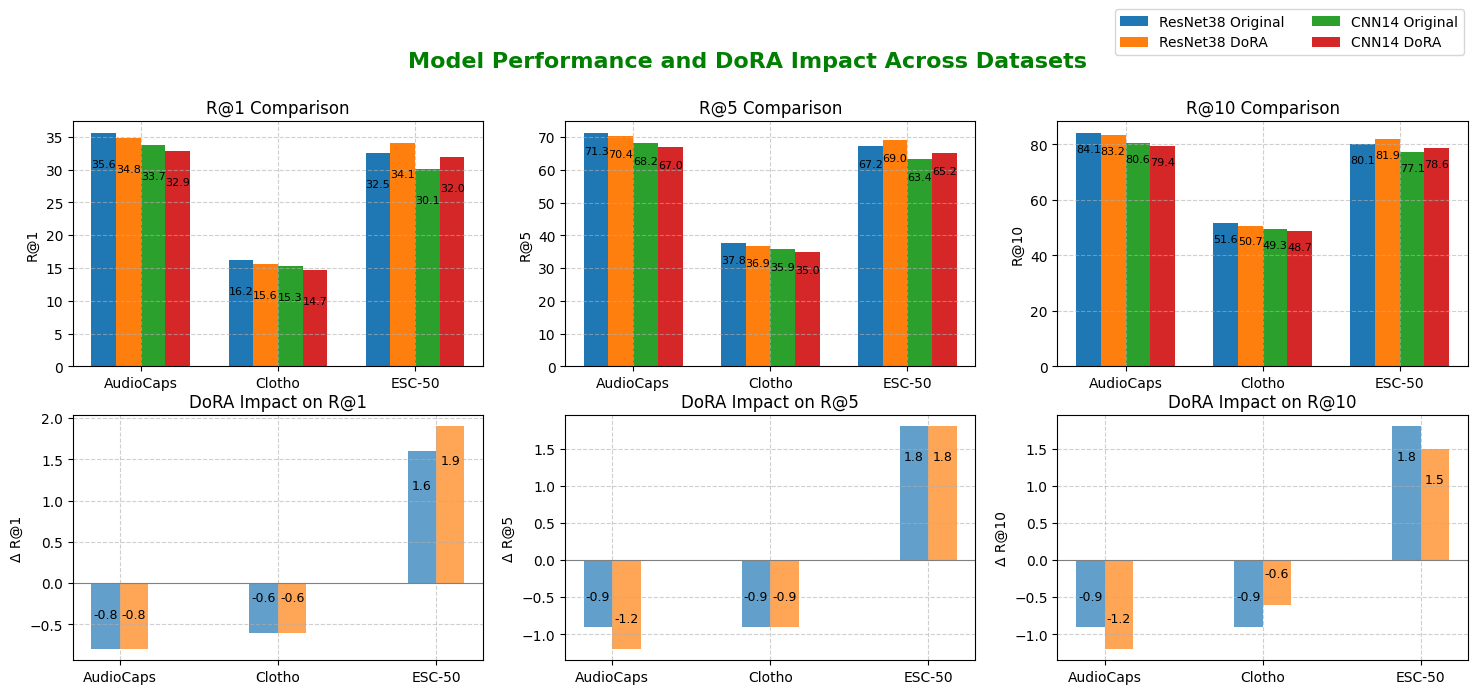

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Data setup
models = ['ResNet38', 'CNN14']
datasets = ['AudioCaps', 'Clotho', 'ESC-50']
recall_types = ['R@1', 'R@5', 'R@10']

results = scores

# Plot combined comparison and impact charts in a row
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
comparison_axes = axes[0]
impact_axes = axes[1]
width = 0.18
x = np.arange(len(datasets))

for idx, metric in enumerate(recall_types):
    # --- Comparison Plot ---
    ax = comparison_axes[idx]
    for i, model in enumerate(models):
        original = results[f"{model}_Original"][metric]
        dora = results[f"{model}_DoRA"][metric]

        orig_pos = x + (i * 2) * width
        dora_pos = x + (i * 2 + 1) * width

        bars1 = ax.bar(orig_pos, original, width, label=f'{model} Original')
        bars2 = ax.bar(dora_pos, dora, width, label=f'{model} DoRA')

        for bar in bars1 + bars2:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height - 4, f'{height:.1f}',
                    ha='center', va='top', color='black', fontsize=8)

    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(datasets)
    ax.grid(True, linestyle='--', alpha=0.6)

    # --- Impact Plot ---
    ax = impact_axes[idx]
    for i, model in enumerate(models):
        delta = np.array(results[f"{model}_DoRA"][metric]) - np.array(results[f"{model}_Original"][metric])
        pos = x + i * width
        bars = ax.bar(pos, delta, width, label=f'{model} (Δ)', alpha=0.7)

        for j, val in enumerate(delta):
            ax.text(pos[j], val - 0.5 if val > 0 else val + 0.5,
                    f'{val:.1f}', ha='center', va='bottom' if val > 0 else 'top',
                    color='black', fontsize=9)

    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_ylabel(f'Δ {metric}')
    ax.set_title(f'DoRA Impact on {metric}')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(datasets)
    ax.grid(True, linestyle='--', alpha=0.6)

# Legends
handles, labels = comparison_axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=(0.7, 1.05))

plt.tight_layout(rect=[0, 1, 1, 0.98])
plt.suptitle("Model Performance and DoRA Impact Across Datasets",color='green',fontweight='bold', fontsize=16)
plt.show()


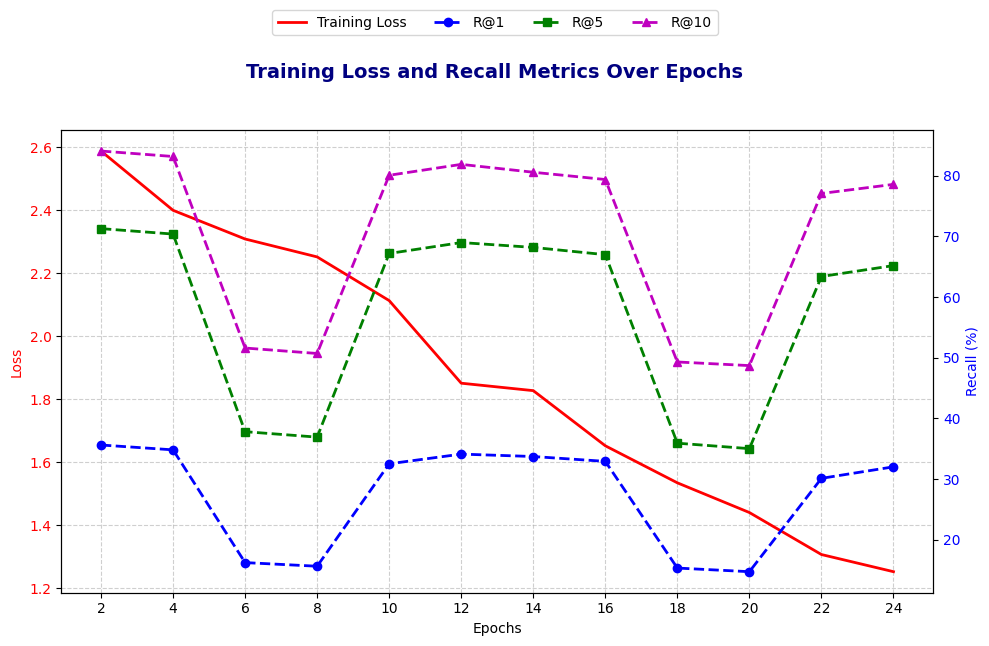

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Plot training loss
ax1.plot(epochs, train_loss, 'r-', label='Training Loss', linewidth=2)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xticks(epochs)

# Twin axis for recall metrics
ax2 = ax1.twinx()
ax2.plot(epochs, r_at_1, 'b--o', label='R@1', linewidth=2)
ax2.plot(epochs, r_at_5, 'g--s', label='R@5', linewidth=2)
ax2.plot(epochs, r_at_10, 'm--^', label='R@10', linewidth=2)
ax2.set_ylabel('Recall (%)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

# Title and legend
fig.suptitle('Training Loss and Recall Metrics Over Epochs', fontsize=14, fontweight='bold', color='navy')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
